# Last.fm Music Recommender — Analysis

**ESADE — Recommender Systems (Individual Project, Music track).**

This notebook walks through the prototype end to end and interprets the results.
All heavy lifting lives in `src/`; here we orchestrate and *explain*.

Report structure: Introduction · Dataset · EDA · Algorithms · Evaluation protocol ·
Results · Examples · Limitations · Conclusion.

> Run from the project root with the project venv kernel. If you haven't yet:
> `python scripts/download_data.py`.

## 1. Introduction

We build and compare nine recommenders on the **Last.fm HetRec 2011** dataset,
spanning non-personalized baselines, content-based filtering, collaborative
filtering (item-item & user-user), matrix factorization (a from-scratch implicit
ALS and a library SVD), and a social/friend-based model. Crucially, we evaluate
them on **accuracy and beyond-accuracy** metrics, because — as the brief stresses
— accuracy alone hides popularity bias and lack of novelty/diversity.

The signal is **implicit feedback**: play counts, not star ratings. Our core
modelling choice is to use `weight = log1p(plays)` everywhere.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data_loading as dl
from src.pipeline import prepare_data, build_models
from src.evaluation import evaluate_all
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 2. Dataset

Last.fm HetRec 2011 (GroupLens): 1 892 users, 17 632 artists, ~92 800 user–artist
play counts, ~11 900 tags, and a 12 717-edge friend graph. Implicit feedback,
non-commercial research license (cite Last.fm + HetRec'11).

**Preprocessing** (see `src/data_loading.py`): drop users/artists with < 5
interactions (cold-start noise), take `log1p(plays)` as the modelling weight,
build per-artist tag documents for content features, and split **per user**
(80/20) so every test user is also in training.

In [2]:
data = prepare_data()
ratings, items, friends = data['ratings'], data['items'], data['friends']
train, test = data['train'], data['test']
stats = dl.describe_dataset(ratings, items)

=== Dataset summary ===
Users           : 1,859
Items (artists) : 2,823
Interactions    : 71,355
Sparsity        : 98.640% empty
Avg artists/user: 38.4
Avg users/artist: 25.3
Plays: median=287, max=352,698

Top popular artists:
  Lady Gaga                      610 listeners
  Britney Spears                 522 listeners
  Rihanna                        484 listeners
  The Beatles                    480 listeners
  Katy Perry                     473 listeners
  Madonna                        429 listeners
  Avril Lavigne                  417 listeners
  Christina Aguilera             407 listeners
  Muse                           400 listeners
  Paramore                       399 listeners


## 3. Exploratory data analysis

Two things dominate this dataset and drive every design decision:
1. **Extreme sparsity** (~98.6% of the user×artist matrix is empty).
2. **A heavy long tail**: a handful of pop superstars (Lady Gaga, Britney Spears)
   have hundreds of listeners while most artists have a handful — and play counts
   within a user span several orders of magnitude (hence `log1p`).

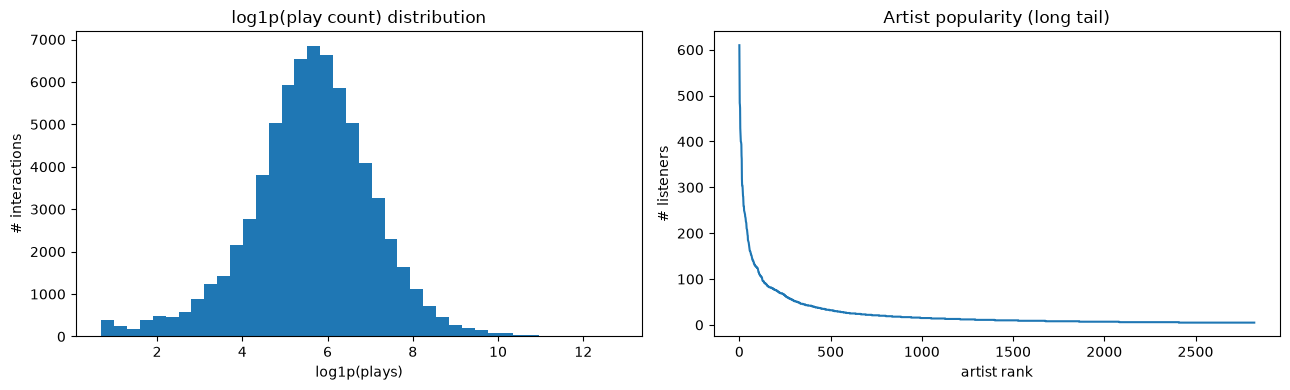

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(np.log1p(ratings[config.RAW_WEIGHT_COL]), bins=40)
ax[0].set(title='log1p(play count) distribution', xlabel='log1p(plays)', ylabel='# interactions')
per_item = ratings.groupby(config.ITEM_COL)[config.USER_COL].nunique().sort_values(ascending=False)
ax[1].plot(per_item.values)
ax[1].set(title='Artist popularity (long tail)', xlabel='artist rank', ylabel='# listeners')
plt.tight_layout(); plt.show()

## 4. Algorithms

All recommenders share `fit` / `recommend(user, train, n)`. See `src/` for the
math and inline explanations. In short:

- **Baselines** — most-popular, highest-average (min listeners), random.
- **Content-based** — TF-IDF over tags; user profile = mean-centered, play-weighted
  sum of tag vectors; cosine scoring.
- **Item-item / user-user CF** — cosine similarity on the `log1p` matrix, top-k
  neighbourhood.
- **Implicit ALS** — Hu-Koren-Volinsky: confidence `c = 1 + α·w` over binary
  preference, solved by alternating ridge regression (from scratch).
- **Surprise SVD** — biased SVD on log-plays as pseudo-ratings (library baseline).
- **Friends/social** — score artists by friends' listening (trust-based CF).

In [4]:
models, cb_model = build_models(train, items, friends)
names = dict(zip(items[config.ITEM_ID_COL], items[config.TITLE_COL]))
list(models)

['most_popular',
 'highest_average',
 'random',
 'content_based',
 'item_item_cf',
 'user_user_cf',
 'implicit_als',
 'friends_social',
 'surprise_svd']

## 5. Evaluation protocol

Top-N (N=10) ranking with **binary relevance**: a recommendation is relevant if
it is one of the user's held-out artists. We average per-user metrics over all
test users. Accuracy: Precision/Recall/NDCG/MRR/Hit-Rate. Beyond-accuracy:
coverage, novelty (self-information), intra-list diversity (content), and average
popularity (popularity-bias indicator).

In [5]:
# Reuse precomputed results if present (main.py), else compute now.
csv = config.RESULTS_DIR / 'metrics.csv'
if csv.exists():
    metrics = pd.read_csv(csv, index_col=0)
else:
    users = sorted(test[config.USER_COL].unique())
    metrics = evaluate_all(models, train, test, users, k=config.TOP_K, cb_model=cb_model)
metrics

,precision,recall,ndcg,mrr,hit_rate,coverage,novelty,diversity,avg_popularity,n_eval_users
most_popular,0.0713,0.0837,0.0903,0.2130,0.4266,0.0089,2.4154,0.6517,353.0310,1859.0000
highest_average,0.0213,0.0268,0.0212,0.0425,0.1850,0.0057,5.0970,0.8740,111.1113,1859.0000
random,0.0026,0.0036,0.0031,0.0074,0.0258,0.9982,7.4631,0.9562,19.6103,1859.0000
content_based,0.0679,0.0931,0.0928,0.2039,0.4416,0.7921,6.5776,0.3996,42.6003,1859.0000
item_item_cf,0.0139,0.0201,0.0173,0.0385,0.1226,0.9486,6.8374,0.8307,31.8133,1859.0000
user_user_cf,0.0278,0.0343,0.0304,0.0687,0.2265,0.5792,6.1566,0.8747,52.7792,1859.0000
implicit_als,0.1195,0.1532,0.1468,0.2914,0.6740,0.5391,4.9072,0.7500,94.8575,1859.0000
friends_social,0.1243,0.1532,0.1718,0.3739,0.6138,0.6334,4.4879,0.7114,148.2188,1859.0000
surprise_svd,0.0310,0.0370,0.0411,0.1137,0.2469,0.0365,4.4867,0.8453,169.7571,1859.0000


## 6. Results & discussion

Representative run (`@10`):

| model | precision | ndcg | coverage | novelty | avg_pop |
|---|---|---|---|---|---|
| friends_social | **0.124** | **0.172** | 0.63 | 4.5 | 148 |
| implicit_als   | 0.120 | 0.147 | 0.54 | 4.9 | 95 |
| most_popular   | 0.071 | 0.090 | **0.01** | **2.4** | **353** |
| content_based  | 0.068 | 0.093 | 0.79 | 6.6 | 43 |
| user_user_cf   | 0.028 | 0.030 | 0.58 | 6.2 | 53 |
| item_item_cf   | 0.014 | 0.017 | 0.95 | 6.8 | 32 |
| random         | 0.003 | 0.003 | **1.00** | **7.5** | **20** |

**Key findings.**

1. **The social signal is the single strongest predictor.** `friends_social` tops
   precision, NDCG and MRR — on Last.fm, *who you are friends with* predicts taste
   better than listening-overlap CF. A genuinely interesting, dataset-specific
   result that justified bringing `user_friends.dat` into scope.
2. **Implicit ALS is the best content-agnostic personalised model**, and the
   correct tool for implicit feedback (it weights confidence, not just presence).
3. **Popularity bias is stark.** `most_popular` gets respectable precision but
   ~1% coverage, the lowest novelty, and by far the highest average popularity —
   it recommends the same superstars to everyone. `random` is the mirror image:
   useless accuracy, perfect coverage/novelty.
4. **Content-based trades accuracy for reach**: strong coverage and novelty but
   low intra-list *diversity* — by construction it recommends artists that sound
   tag-alike, so a single user's list is narrow.
5. **Item-item CF underperforms user-user here.** On sparse implicit data, plain
   cosine item similarity is dominated by co-listening with popular artists; this
   is a known weakness that BM25/TF-IDF re-weighting or tuning `k` would address
   (left as future work — see limitations).

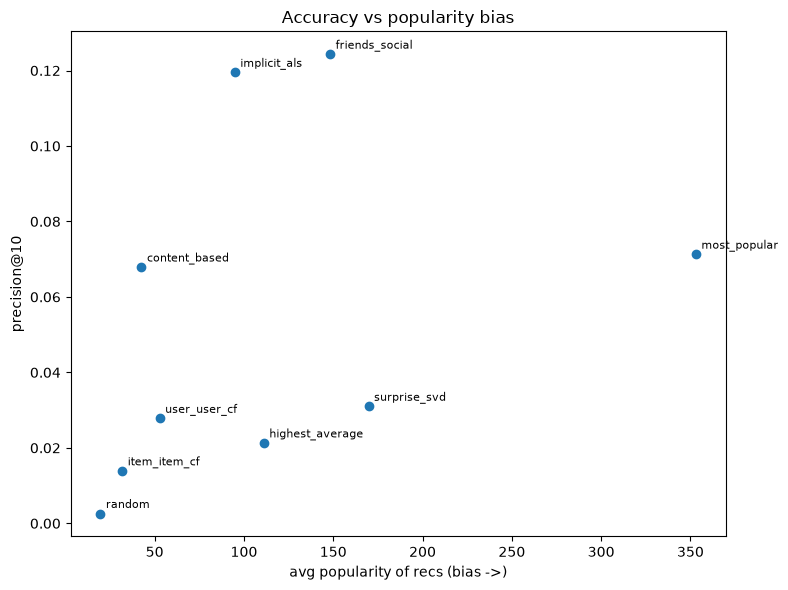

In [6]:
# Accuracy vs popularity-bias tradeoff — the headline picture.
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(metrics['avg_popularity'], metrics['precision'])
for name, row in metrics.iterrows():
    ax.annotate(name, (row['avg_popularity'], row['precision']), fontsize=8,
                xytext=(4,4), textcoords='offset points')
ax.set(xlabel='avg popularity of recs (bias ->)', ylabel='precision@10',
       title='Accuracy vs popularity bias'); plt.tight_layout(); plt.show()

## 7. Recommendation examples (3 users)

In [7]:
example_users = (train.groupby(config.USER_COL).size().sort_values(ascending=False)
                 .head(50).sample(3, random_state=config.RANDOM_STATE).index.tolist())
for u in example_users:
    played = (train[train[config.USER_COL]==u].sort_values(config.RAW_WEIGHT_COL, ascending=False).head(5))
    print(f"\nUser {u} listens to: " + ', '.join(names.get(i,str(i)) for i in played[config.ITEM_COL]))
    for m in ['content_based','item_item_cf','implicit_als','friends_social']:
        recs = [names.get(i,str(i)) for i,_ in models[m].recommend(u, train, n=5)]
        print(f"  {m:<15}: {', '.join(recs) or '(none)'}")


User 741 listens to: Linkin Park, Sum 41, The Killers, The Bravery, Anberlin
  content_based  : Taproot, Adema, P.O.D., Korn, Deftones
  item_item_cf   : Lacuna Coil, Dead by Sunrise, Spinnerette, Brandon Flowers, The Fratellis
  implicit_als   : Green Day, Angels & Airwaves, The Beatles, Placebo, Guns N' Roses
  friends_social : The Gaslight Anthem, The Kooks, Vampire Weekend, Billy Talent, blink-182

User 1564 listens to: Britney Spears, Rihanna, Madonna, Katy Perry, Glee Cast
  content_based  : Lady Gaga, Hadise, Cher, Christina Aguilera, Gwen Stefani
  item_item_cf   : Ricky Martin, BoA, Mandy Moore, Robyn, Backstreet Boys
  implicit_als   : Anahí, Belinda, Nicole Scherzinger, Jessie J, Vanessa Hudgens
  friends_social : Lady Gaga, Beyoncé, Christina Aguilera, Shakira, Avril Lavigne

User 534 listens to: Depeche Mode, Britney Spears, Christina Aguilera, Marilyn Manson, Beyoncé
  content_based  : Camouflage, Yazoo, Orchestral Manoeuvres in the Dark, Soft Cell, Erasure


  item_item_cf   : David Bowie, Duran Duran, Eurythmics, Gary Numan, Tears for Fears
  implicit_als   : Enrique Iglesias, t.A.T.u., Keane, Linkin Park, Michael Jackson
  friends_social : Rihanna, Muse, Kylie Minogue, Avril Lavigne, Mariah Carey


## 8. Limitations

- **Implicit feedback is ambiguous**: absence ≠ dislike; high play counts may be
  background noise. We mitigate with `log1p` + ALS confidence weighting, not solve.
- **No hyperparameter tuning**: `k` (neighbours) and latent factors use sensible
  defaults; a grid search would likely lift CF/MF, especially item-item.
- **Item-item similarity is popularity-skewed**; BM25/TF-IDF weighting is the
  standard fix.
- **Cold start**: new users/artists (filtered out here) need content or social
  fallbacks.
- **Single random split**: cross-validation would tighten the estimates.
- **Friends model coverage**: undefined for users with no friends.

## 9. Conclusion

No single model wins on every axis. For raw top-N accuracy on Last.fm, the
**social** and **implicit-ALS** models lead; **most-popular** is a deceptively
strong but heavily biased baseline; **content-based** maximises reach and novelty
at an accuracy cost. The right production choice is a **hybrid** — e.g. ALS or
social for the core ranking, blended with content for novelty and cold start —
tuned against the beyond-accuracy metrics, not accuracy alone.